In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix



# Dataset Loading

In [2]:
df = pd.read_csv("customer_churn_exam_dataset_3500 - customer_churn_exam_dataset_3500.csv")

In [3]:
df.head() # See the First 5 rows the Dataset

,CustomerID,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn
0,C0001,__35__,Male,South,Basic,16.62,2,5,__27.0__,Quarterly,Card,Yes,4,26,0,1,0
1,C0002,26,Male,North,Standard,46.23,__4__,0,46.1,Monthly,UPI,Yes,5,11,0,2,1
2,C0003,31,Female,North,Standard,43.04,32,0,27.2,NaN,UPI,Yes,7,6,2,3,0
3,C0004,34,Male,East,Basic,29.19,20,4,25.1,Monthly,Bank Transfer,Yes,4,19,0,4,0
4,C0005,38,Female,North,Basic,24.95,1,4,49,Monthly,Cash,No,3,25,0,3,1


In [4]:
df.tail() ## See the Last 5 rows the Dataset

,CustomerID,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn
3495,C3496,24,Female,North,Standard,46.28,1,6,29.3,Quarterly,Bank Transfer,Yes,3,14,1,2,0
3496,C3497,32,Female,South,Standard,34.13,3,1,47.5,Monthly,Card,Yes,6,14,0,1,0
3497,C3498,50,NaN,__value__,Basic,"""31.26""",31,6,27.5,Monthly,UPI,Yes,2,16,2,3,1
3498,C3499,38,Female,Central,Basic,11.08,7,3,35.4,Yearly,Bank Transfer,Yes,8,23,2,1,0
3499,C3500,53,Female,South,NaN,59.22,2,0,21.8,Monthly,Card,No,2,6,3,2,1


In [5]:
df.info() # In this dataset , i see there are almost 17 columns where only 1 contains int64 datatype and rest of them are string.

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   CustomerID            3500 non-null   str  
 1   Age                   3428 non-null   str  
 2   Gender                3432 non-null   str  
 3   Region                3448 non-null   str  
 4   PlanType              3445 non-null   str  
 5   MonthlyCharges        3388 non-null   str  
 6   TenureMonths          3440 non-null   str  
 7   SupportTickets        3434 non-null   str  
 8   AvgMonthlyUsageHours  3402 non-null   str  
 9   ContractType          3431 non-null   str  
 10  PaymentMethod         3446 non-null   str  
 11  AutoPay               3440 non-null   str  
 12  SatisfactionScore     3422 non-null   str  
 13  LastLoginDays         3453 non-null   str  
 14  ReferralCount         3475 non-null   str  
 15  DeviceCount           3468 non-null   str  
 16  Churn            

In [6]:
df.describe()

,Churn
count,3500.000000
mean,0.162000
std,0.368503
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [7]:
df.shape # In our dataset i see almost 3500 rows and 187 columns on this dataset.

(3500, 17)

In [8]:
df.columns # See the column names of my dataset

Index(['CustomerID', 'Age', 'Gender', 'Region', 'PlanType', 'MonthlyCharges',
       'TenureMonths', 'SupportTickets', 'AvgMonthlyUsageHours',
       'ContractType', 'PaymentMethod', 'AutoPay', 'SatisfactionScore',
       'LastLoginDays', 'ReferralCount', 'DeviceCount', 'Churn'],
      dtype='str')

# Data Cleaning

Now  check the nan valus which is present on this dataset and handle it using mean, std, bfill , ffill etc 

# "AGE" 

In [9]:
# Check the Unique values 
df['Age'].unique() 

<StringArray>
[ '__35__',      '26',      '31',      '34',      '38',      '36',      '28',
      '58',      '23',      '29',      '37',      '39',      '18',      '41',
      '32',      '52',      '60',      '24',      '19',      '50',      '51',
      '25',      '43',      '35',      '33',      '30',      '40',      '44',
      '55',      '42',      '45',      '46',      '59',      '21',      '49',
      '53',      '47',      '27',       nan,      '48',      '54',      '63',
      '66', 'unknown',      '22',      '20',      '57',      '70',      '64',
      '61',      '56',  '__31__',      '""',  '__27__',  '__46__',  '__53__',
  '__41__',  '__52__',      '62',  '__34__',  '__36__',  '__21__',  '__45__',
  '__29__',  '__49__',  '__39__',  '__26__',      '65',  '__18__',  '__37__',
  '__38__',      '67',  '__43__',  '__24__',  '__48__',  '__42__',  '__54__',
  '__30__',  '__33__',  '__25__',      '68']
Length: 81, dtype: str

In this column , there are almost 81 unique values ... most concerning thing is all the data are not numeric . Most of them are Numeric and rest of them are string.

In [10]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce') # convert the data into numeric

Using pd.to_numeric , which is used to make all the data type into numeric what ever the data type present on this column

In [11]:
df['Age'].unique()

array([nan, 26., 31., 34., 38., 36., 28., 58., 23., 29., 37., 39., 18.,
       41., 32., 52., 60., 24., 19., 50., 51., 25., 43., 35., 33., 30.,
       40., 44., 55., 42., 45., 46., 59., 21., 49., 53., 47., 27., 48.,
       54., 63., 66., 22., 20., 57., 70., 64., 61., 56., 62., 65., 67.,
       68.])

All the values are converted into numeric form .

In [12]:
df['Age']= df['Age'].fillna(df['Age'].mean()) # Handle the nan value using mean.

Using "fillna" to handle the nan values which is present on this column, where i handle the nan values using the Mean . Besically there are 3 standertd types where we handling nan values on this types of numeric columns. Standerd_Deviation , Mean and medium this 3 are known as standerd type of handling the numeric data.

In [13]:
df.isna().sum() # See there is no nan values on the colunm "AGE"

CustomerID                0
Age                       0
Gender                   68
Region                   52
PlanType                 55
MonthlyCharges          112
TenureMonths             60
SupportTickets           66
AvgMonthlyUsageHours     98
ContractType             69
PaymentMethod            54
AutoPay                  60
SatisfactionScore        78
LastLoginDays            47
ReferralCount            25
DeviceCount              32
Churn                     0
dtype: int64

In [14]:
df.head()

,CustomerID,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn
0,C0001,36.714329,Male,South,Basic,16.62,2,5,__27.0__,Quarterly,Card,Yes,4,26,0,1,0
1,C0002,26.000000,Male,North,Standard,46.23,__4__,0,46.1,Monthly,UPI,Yes,5,11,0,2,1
2,C0003,31.000000,Female,North,Standard,43.04,32,0,27.2,NaN,UPI,Yes,7,6,2,3,0
3,C0004,34.000000,Male,East,Basic,29.19,20,4,25.1,Monthly,Bank Transfer,Yes,4,19,0,4,0
4,C0005,38.000000,Female,North,Basic,24.95,1,4,49,Monthly,Cash,No,3,25,0,3,1


# "GENDER" column

In [15]:
df['Gender'].unique() # See there are 6 unique valus on this columns .. where most disturbing values is "Non-binary" ,'Unknown","Nan" and "__Value__"

<StringArray>
['Male', 'Female', 'Non-binary', nan, 'unknown', '__value__']
Length: 6, dtype: str

In [16]:
df['Gender'] = df['Gender'].replace({ 
    'unknown': 'others',
    '__value__': 'others'
}) # In this particular part , i replace those disturbing name by "Others"

On this particular part  , there are 6 unique values on this columns , where Male , Female and Unknown are suitable for this column and rest of them are not even connected according to this topic. using replace as a result i replace the unsuitable values in  a suitable word

In [17]:
df['Gender'] = df['Gender'].replace({'Non-binary': 'others'}) # Specially convert "Non_Binary" to "Others"

In [18]:
df['Gender'].unique() # After done the replace job then we see there are 4 types of data on this column

<StringArray>
['Male', 'Female', 'others', nan]
Length: 4, dtype: str

In [19]:
 # Lets handle the nun values on this col 

df['Gender'] = df['Gender'].bfill()

In this part , using "bfill". Besically there are 3 types of handling way we all know .."fillna","bfill","ffill" , in that case i use bfill , it means program replace nan values by their backword value

In [20]:
df.isnull().sum() # see there is no nan valus on the Gender column

CustomerID                0
Age                       0
Gender                    0
Region                   52
PlanType                 55
MonthlyCharges          112
TenureMonths             60
SupportTickets           66
AvgMonthlyUsageHours     98
ContractType             69
PaymentMethod            54
AutoPay                  60
SatisfactionScore        78
LastLoginDays            47
ReferralCount            25
DeviceCount              32
Churn                     0
dtype: int64

# "REGION" column

In [21]:
df['Region'].unique() # See there are 8 unique data on this column

<StringArray>
['South', 'North', 'East', 'West', 'Central', nan, '__value__', 'unknown']
Length: 8, dtype: str

In [22]:
df['Region'] = df['Region'].replace({'__value__': 'unknown'}) # Replace "__value__" to "Unkown"

In [23]:
# Check the Nan values on the column 'Region'
df['Region'].isnull().sum() # There are 52  Nan values on this column

np.int64(52)

In [24]:
df['Region'] = df['Region'].ffill()

In [25]:
df.isnull().sum()

CustomerID                0
Age                       0
Gender                    0
Region                    0
PlanType                 55
MonthlyCharges          112
TenureMonths             60
SupportTickets           66
AvgMonthlyUsageHours     98
ContractType             69
PaymentMethod            54
AutoPay                  60
SatisfactionScore        78
LastLoginDays            47
ReferralCount            25
DeviceCount              32
Churn                     0
dtype: int64

# "PlanType" column

In [26]:
df['PlanType'].unique() # There are 9 unique data on this col

<StringArray>
['Basic', 'Standard', 'Premium', '2', '3', '__value__', nan, '1', 'unknown']
Length: 9, dtype: str

In [27]:
df['PlanType'] = df['PlanType'].replace({
    '1': 'unknown',
    '2': 'unknown',
    '3': 'unknown',
    '__value__': 'unknown' 
}) # In that particular part , replace '1','2','3' and '__value__' using 'Unknown'

In [28]:
df['PlanType'].unique() 

<StringArray>
['Basic', 'Standard', 'Premium', 'unknown', nan]
Length: 5, dtype: str

In [29]:
df['PlanType'].value_counts() # In this column , mostly used type is "Basic" .

PlanType
Basic       1256
Standard    1225
Premium      722
unknown      242
Name: count, dtype: int64

In [30]:
# So , replace nan values using "Basic"
df['PlanType'] = df['PlanType'].fillna('Basic')

In [31]:
df.isnull().sum() # handle the nan values for "PlanType"

CustomerID                0
Age                       0
Gender                    0
Region                    0
PlanType                  0
MonthlyCharges          112
TenureMonths             60
SupportTickets           66
AvgMonthlyUsageHours     98
ContractType             69
PaymentMethod            54
AutoPay                  60
SatisfactionScore        78
LastLoginDays            47
ReferralCount            25
DeviceCount              32
Churn                     0
dtype: int64

# "MonthlyChargea" column

In [32]:
df['MonthlyCharges'].unique() # almost 2598 unique values on this column

<StringArray>
[  '16.62',   '46.23',   '43.04',   '29.19',   '24.95',   '47.99',   '37.51',
   '37.32',    '69.6',   '43.56',
 ...
   '62.86',   '77.44',   '74.99',   '68.97',    '14.9',   '86.03',   '34.13',
 '"31.26"',   '11.08',   '59.22']
Length: 2598, dtype: str

In [33]:
df['MonthlyCharges'] = (df['MonthlyCharges'].astype(str).str.replace('_', ''))

df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].mean())


In this particular part , first convert this column into string as a result we can use str.replace on that particular part

In [34]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
Region                   0
PlanType                 0
MonthlyCharges           0
TenureMonths            60
SupportTickets          66
AvgMonthlyUsageHours    98
ContractType            69
PaymentMethod           54
AutoPay                 60
SatisfactionScore       78
LastLoginDays           47
ReferralCount           25
DeviceCount             32
Churn                    0
dtype: int64

# "TenureMonths" col

In [35]:
df['TenureMonths'].unique()

<StringArray>
[      '2',   '__4__',      '32',      '20',       '1',      '11',      '64',
      '13',      '33',       '5',      '23',      '12',       '4',       '7',
      '18',      '15',      '31',      '43',      '25',       '3',      '42',
      '28',      '36',      '40',      '27',       '6', 'unknown',      '72',
      '14',   '__5__',      '16',       '9',      '51',      '22',      '21',
      '34',       '8',      '17',      '""',      '19',      '60',      '10',
      '70',      '62',      '26',       nan,      '35',      '47',      '52',
      '41',      '24',      '37',      '39',      '46',  '__51__',      '61',
      '59',      '29',      '38',      '67',      '50',      '66',      '48',
      '69',      '45',      '44',      '49',      '30',      '57',      '54',
      '55',   '__3__',   '__1__',  '__18__',  '__37__',      '65',      '56',
      '53',  '__49__',      '71',      '58',      '68',   '__6__',   '__7__',
  '__30__',      '63',  '__22__',  '__10__',   '__

In [36]:
df['TenureMonths'] = (
    df['TenureMonths']
    .astype(str).str.replace('_', '')
)

df['TenureMonths'] = pd.to_numeric(df['TenureMonths'], errors='coerce')

df['TenureMonths'] = df['TenureMonths'].fillna(df['TenureMonths'].mean())


# "SupportTickets" col

In [37]:
df['SupportTickets'].unique()

<StringArray>
[      '5',       '0',       '4',       '2',       '1',       '3',       '7',
       nan,       '8',       '6',      '""',       '9', 'unknown',   '__2__',
   '__5__',   '__4__',      '10',      '11',   '__7__',   '__6__',   '__0__',
   '__1__']
Length: 22, dtype: str

In [38]:
df['SupportTickets'] = (
    df['SupportTickets']
    .astype(str).str.replace('_', '')
)

df['SupportTickets'] = pd.to_numeric(df['SupportTickets'], errors='coerce')

df['SupportTickets'] = df['SupportTickets'].fillna(df['SupportTickets'].mean())


In [39]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
Region                   0
PlanType                 0
MonthlyCharges           0
TenureMonths             0
SupportTickets           0
AvgMonthlyUsageHours    98
ContractType            69
PaymentMethod           54
AutoPay                 60
SatisfactionScore       78
LastLoginDays           47
ReferralCount           25
DeviceCount             32
Churn                    0
dtype: int64

# "AvgMonthlyUsageHours"  col

In [40]:
df['AvgMonthlyUsageHours'].unique()

<StringArray>
['__27.0__',     '46.1',     '27.2',     '25.1',       '49',     '36.8',
     '40.2',     '50.6',     '57.3',     '37.6',
 ...
 '__22.0__',   '"28.1"',     '15.7',   '"44.2"',   '"60.7"',     '12.3',
     '67.7',     '13.5',       '79',   '"55.0"']
Length: 696, dtype: str

In [41]:
df['AvgMonthlyUsageHours'] = (df['AvgMonthlyUsageHours'].astype(str).str.replace('_', ''))

df['AvgMonthlyUsageHours'] = pd.to_numeric(df['AvgMonthlyUsageHours'], errors='coerce')

df['AvgMonthlyUsageHours'] = df['AvgMonthlyUsageHours'].fillna(df['AvgMonthlyUsageHours'].mean())


In [42]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
Region                   0
PlanType                 0
MonthlyCharges           0
TenureMonths             0
SupportTickets           0
AvgMonthlyUsageHours     0
ContractType            69
PaymentMethod           54
AutoPay                 60
SatisfactionScore       78
LastLoginDays           47
ReferralCount           25
DeviceCount             32
Churn                    0
dtype: int64

# "ContractType" col

In [43]:
df['ContractType'].unique()

<StringArray>
['Quarterly', 'Monthly', nan, '3', 'Yearly', '1', '__value__', '2', 'unknown']
Length: 9, dtype: str

In [44]:
df['ContractType'] = df['ContractType'].replace({
    '1': 'unknown',
    '2': 'unknown',
    '3': 'unknown',
    '__value__': 'unknown' 
})

In [45]:
df['ContractType'] = df['ContractType'].bfill()

# "PaymentMethod"  col

In [46]:
df['PaymentMethod'].unique()

<StringArray>
['Card', 'UPI', 'Bank Transfer', 'Cash', nan, '__value__', 'unknown']
Length: 7, dtype: str

In [47]:
df['PaymentMethod'] = df['PaymentMethod'].replace({
    '__value__': 'unknown' })

In [48]:
df['PaymentMethod'] = df['PaymentMethod'].ffill()

# "AutoPay" col

In [49]:
df['AutoPay'].unique()

<StringArray>
['Yes', 'No', nan, '1', '0', 'unknown', '__value__']
Length: 7, dtype: str

In [50]:
df['AutoPay'] = df['AutoPay'].replace({
    '1': 'unknown',
    '0': 'unknown',
    '__value__': 'unknown' 
})

In [51]:
df['AutoPay'] = df['AutoPay'].bfill()

# "SatisfactionScore"  col 

In [52]:
df['SatisfactionScore'].unique()

<StringArray>
[      '4',       '5',       '7',       '3',       '8',       '6',       '1',
   '__6__',   '__7__',       '2', 'unknown',       '9',       nan,      '10',
      '""',   '__1__',   '__5__',   '__2__',   '__8__',   '__9__']
Length: 20, dtype: str

In [53]:
df['SatisfactionScore'] = ( df['SatisfactionScore'].astype(str).str.replace('_', ''))

df['SatisfactionScore'] = pd.to_numeric(df['SatisfactionScore'], errors='coerce')

In [54]:
df['SatisfactionScore'] = df['SatisfactionScore'].fillna(df['SatisfactionScore'].median())

In [55]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
Region                   0
PlanType                 0
MonthlyCharges           0
TenureMonths             0
SupportTickets           0
AvgMonthlyUsageHours     0
ContractType             0
PaymentMethod            0
AutoPay                  0
SatisfactionScore        0
LastLoginDays           47
ReferralCount           25
DeviceCount             32
Churn                    0
dtype: int64

In [56]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Region', 'PlanType', 'MonthlyCharges',
       'TenureMonths', 'SupportTickets', 'AvgMonthlyUsageHours',
       'ContractType', 'PaymentMethod', 'AutoPay', 'SatisfactionScore',
       'LastLoginDays', 'ReferralCount', 'DeviceCount', 'Churn'],
      dtype='str')

In [57]:
df['LastLoginDays'].unique()

<StringArray>
[     '26',      '11',       '6',      '19',      '25',       '0',      '10',
      '13',       '1',      '20',       '9',       '3',      '18',      '12',
      '27',      '30',  '__18__',       '5',      '28',      '22',       '2',
       '8',      '14',      '16',      '24',      '21',      '34',       '7',
       '4',       nan,      '15', 'unknown',      '23',      '44',      '17',
      '29',      '32',      '""',      '31',   '__0__',   '__2__',      '35',
   '__1__',  '__14__',      '39',      '33',      '37',  '__12__',  '__10__',
   '__8__',      '45',   '__7__',      '50',      '41',   '__9__',      '36']
Length: 56, dtype: str

In [58]:
df['LastLoginDays'] = (df['LastLoginDays'].astype(str).str.replace('_', ''))

df['LastLoginDays'] = pd.to_numeric(df['LastLoginDays'], errors='coerce')

df['LastLoginDays'] = df['LastLoginDays'].fillna(df['LastLoginDays'].median())

In [59]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
Region                   0
PlanType                 0
MonthlyCharges           0
TenureMonths             0
SupportTickets           0
AvgMonthlyUsageHours     0
ContractType             0
PaymentMethod            0
AutoPay                  0
SatisfactionScore        0
LastLoginDays            0
ReferralCount           25
DeviceCount             32
Churn                    0
dtype: int64

# "ReferralCount" col

In [60]:
df['ReferralCount'].unique()

<StringArray>
[      '0',       '2',       '4',       '1',      '""',       '3',   '__0__',
       '5',       nan, 'unknown',       '6',       '7',   '__2__',   '__4__',
   '__3__',   '__1__']
Length: 16, dtype: str

In [61]:
df['LastLogiReferralCountnDays'] = (df['ReferralCount'].astype(str).str.replace('_', ''))

df['ReferralCount'] = pd.to_numeric(df['ReferralCount'], errors='coerce')

df['ReferralCount'] = df['ReferralCount'].fillna(df['ReferralCount'].median())

# "DeviceCount" col

In [62]:
df['DeviceCount'].unique()

<StringArray>
[      '1',       '2',       '3',       '4',       '6', 'unknown',       '5',
       nan,      '""',   '__2__',   '__1__',   '__3__',   '__4__']
Length: 13, dtype: str

In [63]:
df['DeviceCount'] = (df['DeviceCount'].astype(str).str.replace('_', ''))

df['DeviceCount'] = pd.to_numeric(df['DeviceCount'], errors='coerce')

df['DeviceCount'] = df['DeviceCount'].fillna(df['DeviceCount'].mean())

In [64]:
df.isnull().sum()

CustomerID                     0
Age                            0
Gender                         0
Region                         0
PlanType                       0
MonthlyCharges                 0
TenureMonths                   0
SupportTickets                 0
AvgMonthlyUsageHours           0
ContractType                   0
PaymentMethod                  0
AutoPay                        0
SatisfactionScore              0
LastLoginDays                  0
ReferralCount                  0
DeviceCount                    0
Churn                          0
LastLogiReferralCountnDays    25
dtype: int64

# "LastLogiReferralCountnDays" col

In [65]:
df['LastLogiReferralCountnDays'].unique()

<StringArray>
['0', '2', '4', '1', '""', '3', '5', nan, 'unknown', '6', '7']
Length: 11, dtype: str

In [66]:
df['LastLogiReferralCountnDays'] = (df['LastLogiReferralCountnDays'].astype(str).str.replace('_', ''))

df['LastLogiReferralCountnDays'] = pd.to_numeric(df['LastLogiReferralCountnDays'], errors='coerce')

df['LastLogiReferralCountnDays'] = df['LastLogiReferralCountnDays'].fillna(df['LastLogiReferralCountnDays'].median())

In [67]:
df['Churn'] =df['Churn'].fillna(df['Churn'].median())

In [68]:

df.isnull().sum()

CustomerID                    0
Age                           0
Gender                        0
Region                        0
PlanType                      0
MonthlyCharges                0
TenureMonths                  0
SupportTickets                0
AvgMonthlyUsageHours          0
ContractType                  0
PaymentMethod                 0
AutoPay                       0
SatisfactionScore             0
LastLoginDays                 0
ReferralCount                 0
DeviceCount                   0
Churn                         0
LastLogiReferralCountnDays    0
dtype: int64

In that particular part , i handle the nan values which is present in my dataset

In [69]:
#Find Duplicated values
df.duplicated().sum()

np.int64(0)

check is that any duplicated column are present on this dataset

In [70]:
df.head()

,CustomerID,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn,LastLogiReferralCountnDays
0,C0001,36.714329,Male,South,Basic,16.62,2.0,5.0,27.0,Quarterly,Card,Yes,4.0,26.0,0.0,1.0,0,0.0
1,C0002,26.000000,Male,North,Standard,46.23,4.0,0.0,46.1,Monthly,UPI,Yes,5.0,11.0,0.0,2.0,1,0.0
2,C0003,31.000000,Female,North,Standard,43.04,32.0,0.0,27.2,Monthly,UPI,Yes,7.0,6.0,2.0,3.0,0,2.0
3,C0004,34.000000,Male,East,Basic,29.19,20.0,4.0,25.1,Monthly,Bank Transfer,Yes,4.0,19.0,0.0,4.0,0,0.0
4,C0005,38.000000,Female,North,Basic,24.95,1.0,4.0,49.0,Monthly,Cash,No,3.0,25.0,0.0,3.0,1,0.0


In [71]:
df = df.drop(['CustomerID'],axis=1) # In that case ,drop "CustomeId" column

In this particular part , i just drop the "CustomerID" column because this is not needed to build a prefect model

In [72]:
df.head()

,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn,LastLogiReferralCountnDays
0,36.714329,Male,South,Basic,16.62,2.0,5.0,27.0,Quarterly,Card,Yes,4.0,26.0,0.0,1.0,0,0.0
1,26.000000,Male,North,Standard,46.23,4.0,0.0,46.1,Monthly,UPI,Yes,5.0,11.0,0.0,2.0,1,0.0
2,31.000000,Female,North,Standard,43.04,32.0,0.0,27.2,Monthly,UPI,Yes,7.0,6.0,2.0,3.0,0,2.0
3,34.000000,Male,East,Basic,29.19,20.0,4.0,25.1,Monthly,Bank Transfer,Yes,4.0,19.0,0.0,4.0,0,0.0
4,38.000000,Female,North,Basic,24.95,1.0,4.0,49.0,Monthly,Cash,No,3.0,25.0,0.0,3.0,1,0.0


# Data Visualization

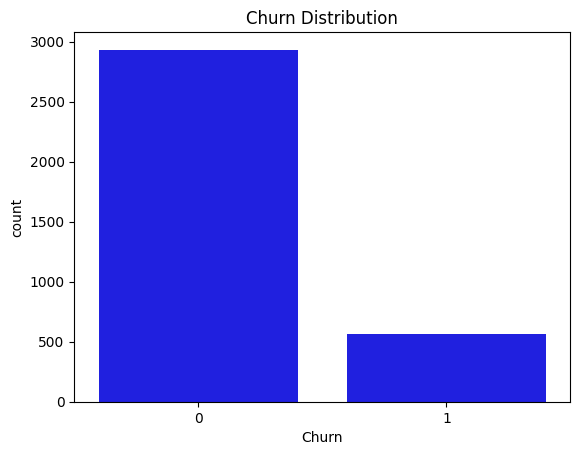

In [73]:
# Churn Distribution
sns.countplot(x = 'Churn' ,data = df ,color="blue")
plt.title("Churn Distribution")
plt.show()

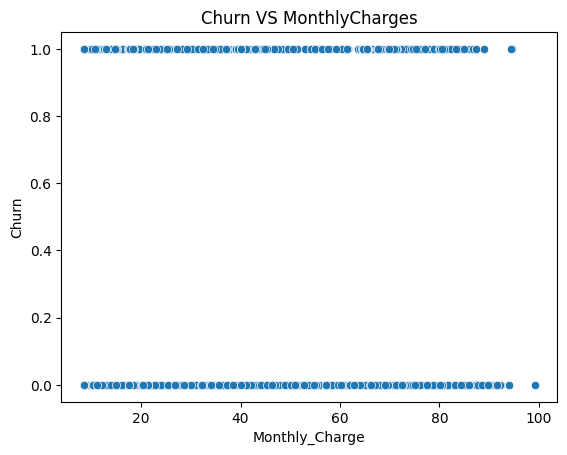

In [74]:
#  Churn VS MonthlyCharge
sns.scatterplot(x='MonthlyCharges' , y='Churn', data=df)
plt.title('Churn VS MonthlyCharges')
plt.xlabel('Monthly_Charge')
plt.ylabel('Churn')
plt.show()

C:\Users\INTEL\AppData\Local\Temp\ipykernel_19188\2220942335.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "Churn" , y = 'TenureMonths' , data = df , palette='Set2')


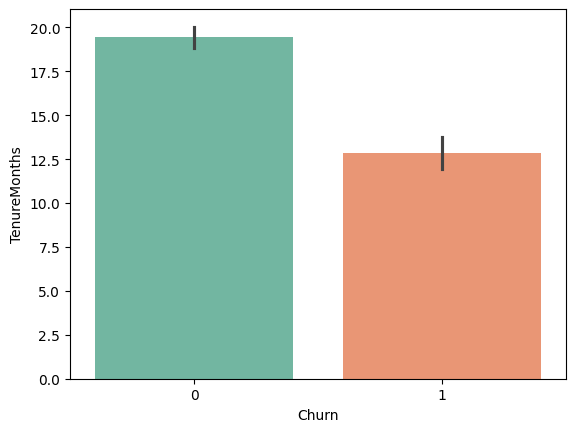

In [75]:
# TenueeMonths VS Churn

sns.barplot(x = "Churn" , y = 'TenureMonths' , data = df , palette='Set2')
plt.show()

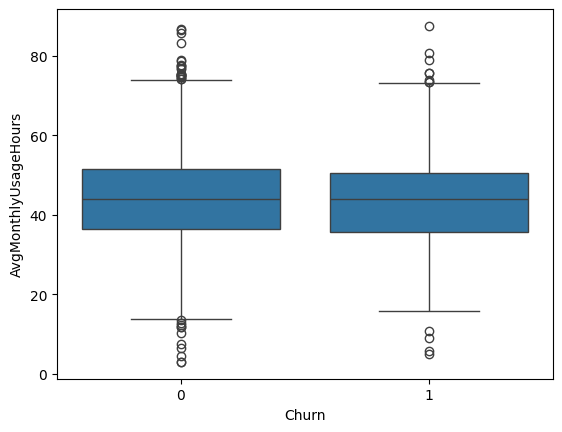

In [76]:
# Avg_Month VS Churn
sns.boxplot(x = "Churn" , y = 'AvgMonthlyUsageHours' , data = df )
plt.show()

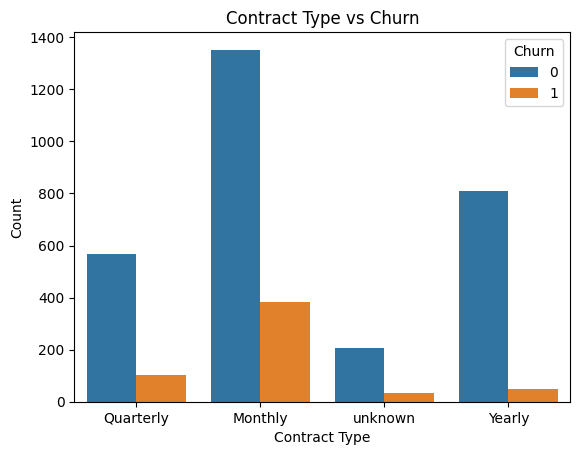

In [77]:
# Contract_Type VS Churn
sns.countplot(x='ContractType', hue='Churn', data=df )

plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.title("Contract Type vs Churn",fontsize=12)
plt.show()

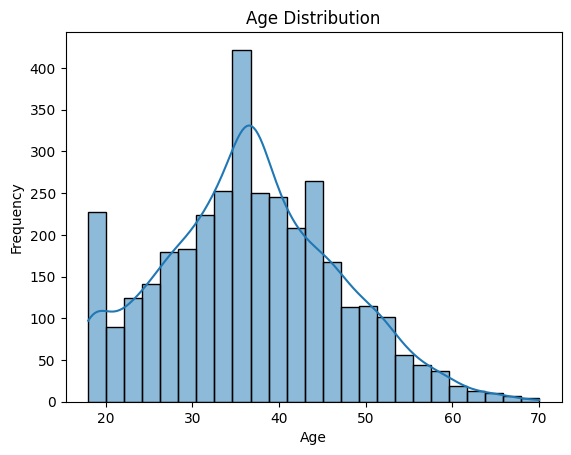

In [78]:
# Age Distribution 
sns.histplot(data=df, x='Age', bins=25, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

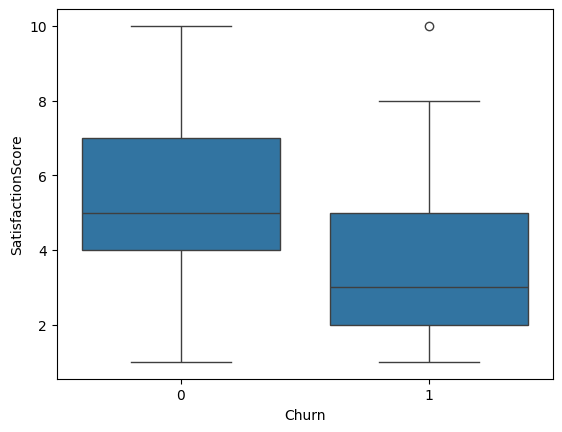

In [79]:
# SatisfactionScore VS Churn
sns.boxplot(x = "Churn" , y = 'SatisfactionScore' , data = df)
plt.show()

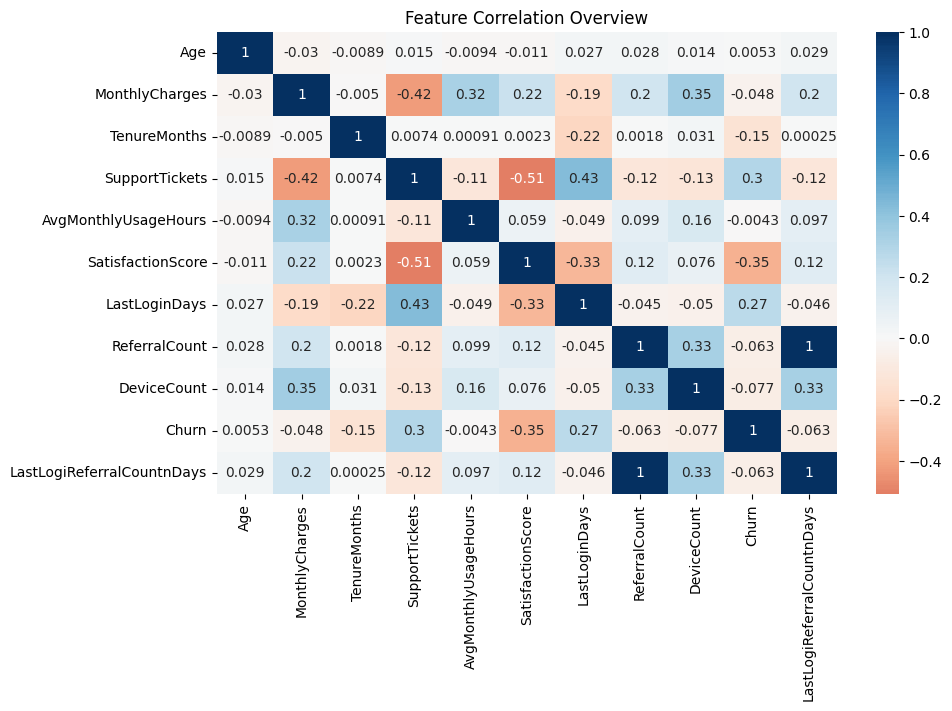

In [80]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),cmap='RdBu', center=0,annot=True)

plt.title("Feature Correlation Overview")
plt.show()

<Axes: ylabel='None'>

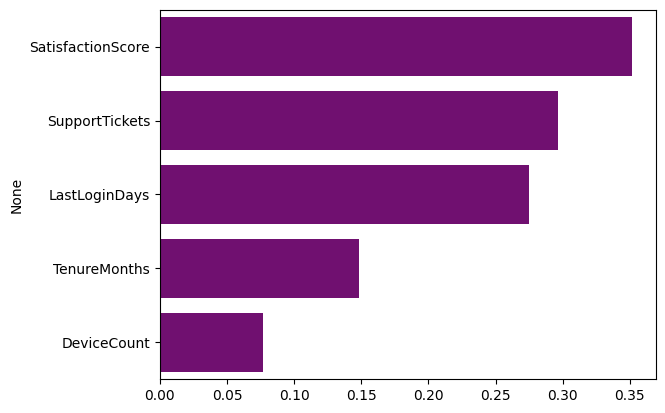

In [81]:
corr1 = df.corr(numeric_only=True)['Churn'].drop('Churn')

top_features = corr1.abs().sort_values(ascending=False).head(5)

sns.barplot(x=top_features.values, y=top_features.index , color="purple")

<Axes: xlabel='TenureMonths', ylabel='Density'>

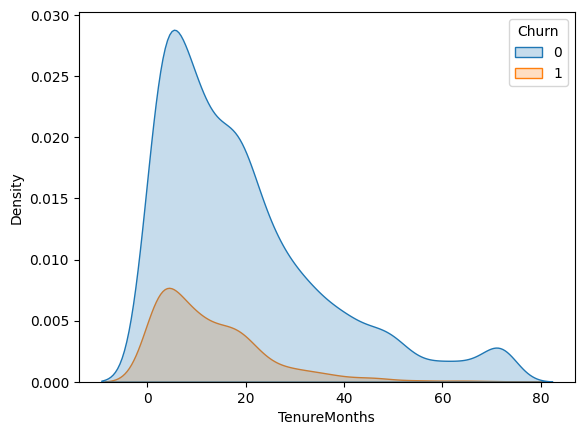

In [82]:
sns.kdeplot(data=df, x='TenureMonths', hue='Churn', fill=True)

# Encoding

In [83]:
ohe = OneHotEncoder() # Creating Object for OneHotEncoding

In [84]:
df.head()

,Age,Gender,Region,PlanType,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,ContractType,PaymentMethod,AutoPay,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn,LastLogiReferralCountnDays
0,36.714329,Male,South,Basic,16.62,2.0,5.0,27.0,Quarterly,Card,Yes,4.0,26.0,0.0,1.0,0,0.0
1,26.000000,Male,North,Standard,46.23,4.0,0.0,46.1,Monthly,UPI,Yes,5.0,11.0,0.0,2.0,1,0.0
2,31.000000,Female,North,Standard,43.04,32.0,0.0,27.2,Monthly,UPI,Yes,7.0,6.0,2.0,3.0,0,2.0
3,34.000000,Male,East,Basic,29.19,20.0,4.0,25.1,Monthly,Bank Transfer,Yes,4.0,19.0,0.0,4.0,0,0.0
4,38.000000,Female,North,Basic,24.95,1.0,4.0,49.0,Monthly,Cash,No,3.0,25.0,0.0,3.0,1,0.0


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         3500 non-null   float64
 1   Gender                      3500 non-null   str    
 2   Region                      3500 non-null   str    
 3   PlanType                    3500 non-null   str    
 4   MonthlyCharges              3500 non-null   float64
 5   TenureMonths                3500 non-null   float64
 6   SupportTickets              3500 non-null   float64
 7   AvgMonthlyUsageHours        3500 non-null   float64
 8   ContractType                3500 non-null   str    
 9   PaymentMethod               3500 non-null   str    
 10  AutoPay                     3500 non-null   str    
 11  SatisfactionScore           3500 non-null   float64
 12  LastLoginDays               3500 non-null   float64
 13  ReferralCount               3500 non-null   

In [86]:
# 1. One-hot encode categorical
df = pd.get_dummies(df,columns=df.select_dtypes(include='object').columns,drop_first=True)


C:\Users\INTEL\AppData\Local\Temp\ipykernel_19188\179660663.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df = pd.get_dummies(df,columns=df.select_dtypes(include='object').columns,drop_first=True)


In [87]:
# 2.Convert bool → int
for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

In [88]:
df.head()

,Age,MonthlyCharges,TenureMonths,SupportTickets,AvgMonthlyUsageHours,SatisfactionScore,LastLoginDays,ReferralCount,DeviceCount,Churn,...,PlanType_unknown,ContractType_Quarterly,ContractType_Yearly,ContractType_unknown,PaymentMethod_Card,PaymentMethod_Cash,PaymentMethod_UPI,PaymentMethod_unknown,AutoPay_Yes,AutoPay_unknown
0,36.714329,16.62,2.0,5.0,27.0,4.0,26.0,0.0,1.0,0,...,0,1,0,0,1,0,0,0,1,0
1,26.000000,46.23,4.0,0.0,46.1,5.0,11.0,0.0,2.0,1,...,0,0,0,0,0,0,1,0,1,0
2,31.000000,43.04,32.0,0.0,27.2,7.0,6.0,2.0,3.0,0,...,0,0,0,0,0,0,1,0,1,0
3,34.000000,29.19,20.0,4.0,25.1,4.0,19.0,0.0,4.0,0,...,0,0,0,0,0,0,0,0,1,0
4,38.000000,24.95,1.0,4.0,49.0,3.0,25.0,0.0,3.0,1,...,0,0,0,0,0,1,0,0,0,0


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         3500 non-null   float64
 1   MonthlyCharges              3500 non-null   float64
 2   TenureMonths                3500 non-null   float64
 3   SupportTickets              3500 non-null   float64
 4   AvgMonthlyUsageHours        3500 non-null   float64
 5   SatisfactionScore           3500 non-null   float64
 6   LastLoginDays               3500 non-null   float64
 7   ReferralCount               3500 non-null   float64
 8   DeviceCount                 3500 non-null   float64
 9   Churn                       3500 non-null   int64  
 10  LastLogiReferralCountnDays  3500 non-null   float64
 11  Gender_Male                 3500 non-null   int64  
 12  Gender_others               3500 non-null   int64  
 13  Region_East                 3500 non-null   

In [90]:
df.columns

Index(['Age', 'MonthlyCharges', 'TenureMonths', 'SupportTickets',
       'AvgMonthlyUsageHours', 'SatisfactionScore', 'LastLoginDays',
       'ReferralCount', 'DeviceCount', 'Churn', 'LastLogiReferralCountnDays',
       'Gender_Male', 'Gender_others', 'Region_East', 'Region_North',
       'Region_South', 'Region_West', 'Region_unknown', 'PlanType_Premium',
       'PlanType_Standard', 'PlanType_unknown', 'ContractType_Quarterly',
       'ContractType_Yearly', 'ContractType_unknown', 'PaymentMethod_Card',
       'PaymentMethod_Cash', 'PaymentMethod_UPI', 'PaymentMethod_unknown',
       'AutoPay_Yes', 'AutoPay_unknown'],
      dtype='str')

In [91]:
x = df.drop(['Churn'],axis =1 )

In [92]:
y = df['Churn']

In this part , drop the target column as a result now we have 2 dataset  , one contains features data and another contain Target data

# Train_Test_Split

In [93]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2,random_state=42)

# Scalling 

In [94]:
sclaer = StandardScaler()
num_cols = [
    'Age',
    'MonthlyCharges',
    'TenureMonths',
    'SupportTickets',
    'AvgMonthlyUsageHours',
    'SatisfactionScore',
    'LastLoginDays',
    'ReferralCount',
    'DeviceCount'
]
x_train[num_cols] = sclaer.fit_transform(x_train[num_cols])
x_test[num_cols] = sclaer.transform(x_test[num_cols])

# Training Model

In [95]:
le = LogisticRegression(max_iter=1000)

In [96]:
model= le.fit(x_train,y_train)

In [97]:
model.score(x_train,y_train)

0.8735714285714286

# Test Model

In [98]:
model.score(x_test,y_test)

0.85

# Prediction

In [99]:
y_pred =model.predict(x_test)
print(y_pred)

[0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0
 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1
 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 

# Model Evalution

# Accuracy Score

In [100]:
acc_score = accuracy_score(y_test,y_pred)
acc_score

0.85

# Classification Report

In [101]:

class_rep = classification_report(y_test,y_pred)
print(class_rep)

              precision    recall  f1-score   support

           0       0.86      0.98      0.91       568
           1       0.75      0.31      0.44       132

    accuracy                           0.85       700
   macro avg       0.80      0.64      0.68       700
weighted avg       0.84      0.85      0.82       700



# Confusion Matrix

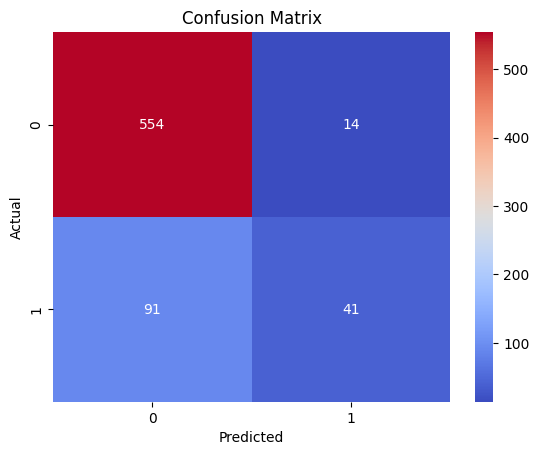

In [102]:
cm = confusion_matrix(y_test,y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Cross_validation_Score

In [103]:
score = cross_val_score(model ,x,y, cv = 5)
print(score)
print("Mean CV Score:", score.mean())

[0.86857143 0.86857143 0.87428571 0.86857143 0.85714286]
Mean CV Score: 0.8674285714285712


# Roc_auc

In [104]:

y_prob = model.predict_proba(x_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.8519659624413145


# Decision Tree

In [105]:
dt = DecisionTreeClassifier()

dt.fit(x_train,y_train)

dt_pred = dt.predict(x_test)

print("Decison Tree Accuracy  : ",accuracy_score(y_test, dt_pred))

Decison Tree Accuracy  :  0.7814285714285715


# Random Forest

In [106]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
rf_pred = rf.predict(x_test)
print("Random Forest Accuracy : ",accuracy_score(y_test, rf_pred) )

Random Forest Accuracy :  0.8357142857142857


# SVM

In [107]:
svm = SVC()

svm.fit(x_train,y_train)

svm_pred = svm.predict(x_test)

print("SVM Accuracy : ", accuracy_score(y_test,svm_pred))

SVM Accuracy :  0.8271428571428572


# KNN

In [108]:
knn = KNeighborsClassifier()

knn.fit(x_train,y_train)

knn_pred = knn.predict(x_test)

print("KNN Accuracy : ", accuracy_score(y_test ,knn_pred))

KNN Accuracy :  0.8271428571428572


# Best Model Accuracy?

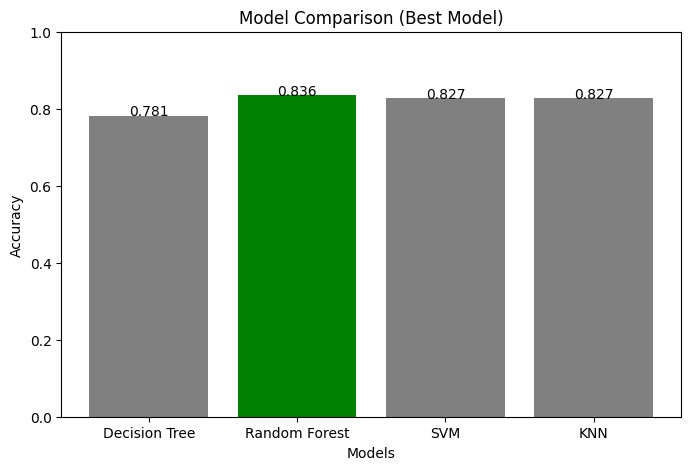

In [109]:

dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)
svm_acc = accuracy_score(y_test, svm_pred)
knn_acc = accuracy_score(y_test, knn_pred)

# Model names & scores
models = ['Decision Tree', 'Random Forest', 'SVM', 'KNN']
scores = [dt_acc, rf_acc, svm_acc, knn_acc]


colors = ['gray', 'gray', 'gray', 'gray']


best_index = scores.index(max(scores))
colors[best_index] = 'green'


plt.figure(figsize=(8,5))

bars = plt.bar(models, scores, color=colors)


for i, v in enumerate(scores):
    plt.text(i, v, str(round(v, 3)), ha='center')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Best Model)")

plt.ylim(0, 1)  
plt.show()

# Identify high-risk customers

In [112]:
high_risk = df[
    (df['LastLoginDays'] > 30) &
    (df['AvgMonthlyUsageHours'] < 5) 
]

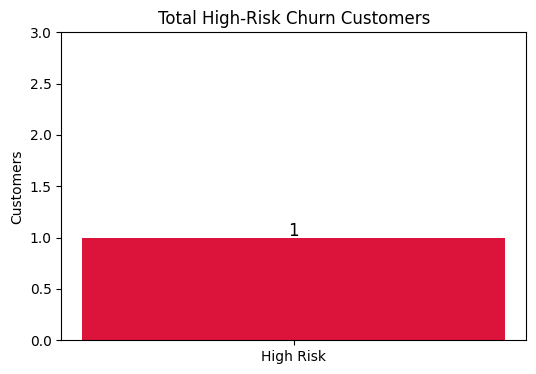

In [123]:
import matplotlib.pyplot as plt

high_risk_count = len(high_risk)

plt.figure(figsize=(6,4))
bars = plt.bar(['High Risk'], [high_risk_count], color='crimson', width=0.4)

plt.title("Total High-Risk Churn Customers")
plt.ylabel("Customers")

# Show value on top
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.02, int(y),
             ha='center', fontsize=12)

plt.ylim(0, high_risk_count + 2)
plt.show()